# Code to fix your flat

This code is basically set up as a notebook style of the flat making process, and goes through each step, ending at the traces for the order. 

In [1]:
# import 
import sys
import os
import argparse
import configparser
from pathlib import Path
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
import scipy.linalg
import scipy.ndimage
import astropy.io.fits as fits

sys.path.append(str(Path.cwd().parents[1]))
from kahe.calibration.make_flat import combine_flats, trace_edges, fit_and_divide
from kahe.utils.math import robust_polyfit, fit_gaussian
from kahe.instruments import nirspec

In [2]:
# === CONSTANTS ===
N = nirspec.N
RIGHT_MARGIN = nirspec.RIGHT_MARGIN
LEFT_MARGIN = nirspec.LEFT_MARGIN 
FLAT_MIN = nirspec.FLAT_MIN
FLAT_MAX = nirspec.FLAT_MAX 
MIN_ORDER_SEPARATION = nirspec.MIN_ORDER_SEPARATION
OVERSCAN_WIDTH = nirspec.OVERSCAN_WIDTH
FILTER = nirspec.NIRSPEC1_70
MIN_FRAMES = 3

In [3]:
# Set the datta directory
flats_dir = "../../../TOI2123_240704/raw/flats"
flats = [fits.getdata(f) for f in Path(flats_dir).glob("*.fits")]
print(f"Loaded {len(flats)} flat frames from {flats_dir}")

Loaded 20 flat frames from ../../../TOI2123_240704/raw/flats


In [4]:
# Set the dark directory 
master_dark =  "../../../TOI2123_240704/cals/TOI2123_240704_masterdark.fits"
with fits.open(Path(master_dark)) as hdul:
    dark_data = hdul[0].data
    dark_header = hdul[0].header

In [5]:
# Combine the flats to visualize the traces 

flat, _ = combine_flats(flats_dir, 
                        masterdark = dark_data)

Processing 20 flat frames...
   [1/20] nspec260724_0008.fits
   [2/20] nspec260724_0024.fits
   [3/20] nspec260724_0012.fits
   [4/20] nspec260724_0013.fits
   [5/20] nspec260724_0025.fits
   [6/20] nspec260724_0009.fits
   [7/20] nspec260724_0014.fits
   [8/20] nspec260724_0018.fits
   [9/20] nspec260724_0022.fits
   [10/20] nspec260724_0023.fits
   [11/20] nspec260724_0019.fits
   [12/20] nspec260724_0015.fits
   [13/20] nspec260724_0016.fits
   [14/20] nspec260724_0020.fits
   [15/20] nspec260724_0021.fits
   [16/20] nspec260724_0017.fits
   [17/20] nspec260724_0026.fits
   [18/20] nspec260724_0010.fits
   [19/20] nspec260724_0007.fits
   [20/20] nspec260724_0011.fits
Combined 20 flat frames


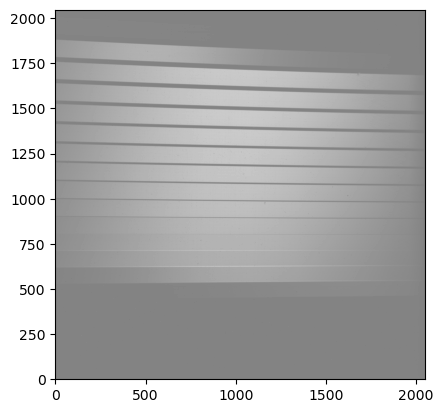

In [6]:
# Imshow the flat
plt.imshow(flat, cmap='gray', origin='lower')

# Great now trace the edges

In [59]:
def trace_edge(image, y_at_center, lower_edge=False, right_margin=30, window=10):
    edges = scipy.ndimage.sobel(image, axis=0)
    if lower_edge: edges *= -1
    edges[edges < 0] = 0
    edges[0:OVERSCAN_WIDTH + 2] = 0
    columns = np.arange(image.shape[1])
    edge_positions = np.ma.MaskedArray(np.zeros(len(columns)))

    prev_pos = y_at_center
    for c in np.arange(int(image.shape[1]/2), image.shape[1]):
        if c > len(columns) - right_margin: 
            edge_positions[c] = np.ma.masked
            continue

        y_lower = max(0, int(prev_pos - window))
        y_upper = min(int(prev_pos + window), image.shape[0] - 1)
        ys = np.arange(y_lower, y_upper)
        
        try:
            coeffs, _, gaussian = fit_gaussian(ys, edges[y_lower : y_upper, c])
            if np.abs(coeffs[1] - prev_pos) > 1 and c != int(image.shape[1]/2):
                edge_positions[c] = np.ma.masked
                continue
            
            edge_positions[c] = coeffs[1]
            prev_pos = edge_positions[c]
        except RuntimeError:
            edge_positions[c] = np.ma.masked

    prev_pos = y_at_center
    for c in np.arange(int(image.shape[1]/2), 0, -1):
        y_lower = max(0, int(prev_pos - window))
        y_upper = min(int(prev_pos + window), image.shape[0] - 1)
        ys = np.arange(y_lower, y_upper)
        
        try:
            coeffs, _, gaussian = fit_gaussian(ys, edges[y_lower : y_upper, c])
            if np.abs(coeffs[1] - prev_pos) > 1 and c != int(image.shape[1]/2):
                edge_positions[c] = np.ma.masked
                continue
            
            edge_positions[c] = coeffs[1]
            prev_pos = edge_positions[c]
        except RuntimeError:
            edge_positions[c] = np.ma.masked
            
    #plt.plot(columns, edge_positions)
    
    fitted_edge_positions = robust_polyfit(columns, edge_positions, 2)
    '''plt.imshow(image)
    plt.axhline(y_lower, color='black')
    plt.axhline(y_upper, color='black')
    if lower_edge:
        plt.plot(fitted_edge_positions, color='g')
    else:
        plt.plot(fitted_edge_positions, color='r')
    plt.show()'''

    return fitted_edge_positions

In [82]:
def trace_edge_improved(image, y_positions, x_positions, lower_edge=False, right_margin=30, window=10):
    """
    Trace an order edge using three known positions to create an initial fit.
    
    Args:
        image: The flat field image
        y_positions: List of 3 y-positions [left, mid, right] for the edge
        x_positions: List of 3 x-positions [left, mid, right] where y_positions were detected
        lower_edge: True if tracing a lower edge (flips edge detection)
        right_margin: Pixels to exclude from right edge
        window: Search window size around expected position
    
    Returns:
        fitted_edge_positions: Polynomial fit of the traced edge
    """
    # Create edge-detected image
    edges = scipy.ndimage.sobel(image, axis=0)
    if lower_edge: 
        edges *= -1
    edges[edges < 0] = 0
    edges[0:OVERSCAN_WIDTH + 2] = 0
    
    columns = np.arange(image.shape[1])
    edge_positions = np.ma.MaskedArray(np.zeros(len(columns)))
    
    # Create initial polynomial fit from the three known positions
    # This gives us a prior for where the edge should be at each column
    n_points = len(x_positions)
    poly_degree = min(2, n_points - 1)
    if n_points == 1:
        # Single point: treat as a flat line at that y-position
        initial_fit = np.full(image.shape[1], y_positions[0])
    else:
        initial_poly_coeffs = np.polyfit(x_positions, y_positions, poly_degree)
        initial_fit = np.polyval(initial_poly_coeffs, np.arange(image.shape[1]))
    # Trace all columns using the initial fit as a guide
    for c in columns:
        if c > len(columns) - right_margin - 1:
            edge_positions[c] = np.ma.masked
            continue
        
        # Use the initial polynomial fit as the expected position
        expected_pos = initial_fit[c]
        
        y_lower = max(0, int(expected_pos - window))
        y_upper = min(int(expected_pos + window), image.shape[0] - 1)
        ys = np.arange(y_lower, y_upper)
        
        try:
            coeffs, _, gaussian = fit_gaussian(ys, edges[y_lower : y_upper, c])
            # Check if the detected position is reasonably close to expected
            if np.abs(coeffs[1] - expected_pos) > 2 * window:
                edge_positions[c] = np.ma.masked
                continue
            
            edge_positions[c] = coeffs[1]
        except (RuntimeError, ValueError):
            edge_positions[c] = np.ma.masked
    
    # Final polynomial fit using all detected positions
    fitted_edge_positions = robust_polyfit(columns, edge_positions, 2)
    
    return fitted_edge_positions

In [96]:
def trace_edges(masterflat, FILTER=None, window=10, percentile=99, 
                show_plots=True, orders=None):
    """Trace spectral order edges in the master flat.
    
    Arguments:sss
        masterflat: Master flat frame
        FILTER: Optional filter bounds tuple (upper, lower)
        window: Window size for edge detection
        percentile: Percentile threshold for peak finding
        show_plots: If True, display diagnostic plots
        orders: Which orders to trace. Options:
            - None (default): trace all detected orders
            - int: trace single order by index (e.g., -3 for third from end)
            - list of ints: trace specific orders by indices (e.g., [0, 2, 5])
            - "all": explicitly trace all orders
        
    Returns:
        upper_edges: Array of upper edge traces
        lower_edges: Array of lower edge traces
    """
    print('Tracing edges...')
    
    if FILTER is None:
        # Detect edges along the vertical (spatial) axis
        edges = scipy.ndimage.sobel(masterflat, axis=0)
        edges[0:OVERSCAN_WIDTH + 2] = 0  # Remove overscan rows

        # Compute the vertical profile at the center columns
        midsection = np.median(edges[:, int(N/2 - window) : int(N/2 + window)], axis=1)
        quarter_section_left = np.median(edges[:, int(N/4 - window) : int(N/4 + window)], axis=1)
        quarter_section_right = np.median(edges[:, int(N*3/4 - window) : int(N*3/4 + window)], axis=1)

        upper_positions_mid = scipy.signal.find_peaks(midsection,
                                                  height=np.percentile(midsection, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]
        lower_positions_mid = scipy.signal.find_peaks(-midsection,
                                                  height=np.percentile(-midsection, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]
        upper_positions_left = scipy.signal.find_peaks(quarter_section_left,
                                                  height=np.percentile(quarter_section_left, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]
        lower_positions_left = scipy.signal.find_peaks(-quarter_section_left,
                                                  height=np.percentile(-quarter_section_left, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]

        upper_positions_right = scipy.signal.find_peaks(quarter_section_right,
                                                  height=np.percentile(quarter_section_right, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]
        lower_positions_right = scipy.signal.find_peaks(-quarter_section_right,
                                                  height=np.percentile(-quarter_section_right, percentile),
                                                  distance=MIN_ORDER_SEPARATION)[0]


                # Top edges - Detect all available orders
        num_detected = min(len(upper_positions_mid), len(lower_positions_mid))
        print(f"  Detected {num_detected} spectral orders")

        # Show detected order positions at different locations
        print(f"  Mid positions: upper={upper_positions_mid}, lower={lower_positions_mid}")
        print(f"  Left positions: upper={upper_positions_left}, lower={lower_positions_left}")
        print(f"  Right positions: upper={upper_positions_right}, lower={lower_positions_right}")

        xs = [N/4, N/2, N*3/4]

        # # Normalize orders to always be a list
        # if orders is None:
        #     # Default: use all detected orders
        #     orders = list(range(num_detected))
        # elif isinstance(orders, int):
        #     orders = [orders]

        # # Resolve negative indices relative to detected orders
        # orders_resolved = []
        # for order_idx in orders:
        #     if order_idx < 0:
        #         resolved_idx = num_detected + order_idx
        #     else:
        #         resolved_idx = order_idx
            
        #     # Validate index
        #     if resolved_idx < 0 or resolved_idx >= num_detected:
        #         raise ValueError(f"Order index {order_idx} out of range [0, {num_detected-1}] or [{-num_detected}, -1]")
            
        #     orders_resolved.append(resolved_idx)

        # print(f"  Tracing order indices: {orders_resolved} (from {num_detected} detected)")

        # # Trace each selected order
        # for idx in orders_resolved:
        #     print(f"    Tracing order at index {idx}...")
        #     ys_upper = [upper_positions_left[idx], upper_positions_mid[idx], upper_positions_right[idx]]
        #     ys_lower = [lower_positions_left[idx], lower_positions_mid[idx], lower_positions_right[idx]]
            
        #     # Sanity check - positions shouldn't differ too much across the detector
        #     if max(ys_upper) - min(ys_upper) > 20:
        #         print(f"    Warning: Upper edge positions vary by {max(ys_upper) - min(ys_upper):.1f} pixels across detector")
        #     if max(ys_lower) - min(ys_lower) > 20:
        #         print(f"    Warning: Lower edge positions vary by {max(ys_lower) - min(ys_lower):.1f} pixels across detector")
            
        #     # Trace edges based on detected positions
        #     upper_edges = trace_edge_improved(masterflat, ys_upper, xs, lower_edge=False)
        #     lower_edges = trace_edge_improved(masterflat, ys_lower, xs, lower_edge=True)

        #     if show_plots:
        #         plt.imshow(masterflat, origin='lower', aspect='auto', cmap='gray')
        #         plt.title(f"Master Flat - Order Index {idx}")
        #         plt.plot(upper_edges, color='lime', label='Upper Edge Trace')
        #         plt.plot(lower_edges, color='magenta', label='Lower Edge Trace')
        #         plt.colorbar(label='Counts')
        #         plt.xlabel("X (columns)")
        #         plt.ylabel("Y (rows)")
        #         plt.legend()
        #         plt.tight_layout()
        #         plt.show()

        #     return np.array([upper_edges]), np.array([lower_edges])
        # Top edges # Skip order 68 We can reliably extract 6 orders 
        available_orders = [69, 70, 71, 72, 73, 74]
        # Make a dictionary object to store the positions of the edges for each order. 68 corresponds to -1 (i.e. the last order)
        edge_positions = {}
        for i, order in enumerate(available_orders):
            edge_positions[order] = -(len(available_orders) - i)
        
        # Now edge_positions = {69: -6, 70: -5, 71: -4, 72: -3, 73: -2, 74: -1}

        # If you want 68 to be -1 (last), reverse the mapping:
        for i, order in enumerate(available_orders):
            edge_positions[order] = -(i + 1)
        # Now edge_positions = {69: -1, 70: -2, 71: -3, 72: -4, 73: -5, 74: -6}

        xs = [N/4, N/2, N*3/4]
        # Look up the requested order positions from the function call: 
        orders = available_orders if orders is None else orders
        # Use the last detected order position from each section
        # Get the index corresponding to the requested order
        order_index = [edge_positions[order] for order in orders]  # Assuming orders is a list of
        for index in order_index: 
            ys_upper = [upper_positions_left[index-1], upper_positions_mid[index], upper_positions_right[index]]
            # asser difference in y vals are less than ~20 (otherwise we're jumping orders)
            assert all(abs(ys_upper[i] - ys_upper[i-1]) < 20 for i in range(1, len(ys_upper))), "Detected order positions differ by more than 20 pixels. Check edge detection."
            ys_lower = [lower_positions_left[index-1], lower_positions_mid[index], lower_positions_right[index]]

            # Trace edges based on detected positions
            upper_edges = trace_edge_improved(masterflat, ys_upper, xs, lower_edge=False)
            lower_edges = trace_edge_improved(masterflat, ys_lower, xs, lower_edge=True)

            if show_plots:
                plt.imshow(masterflat, origin='lower', aspect='auto', cmap='gray')
                plt.title("Master Flat with Detected Edge Positions")
                plt.plot(upper_edges, color='lime', label='Upper Edge Trace')
                plt.plot(lower_edges, color='magenta', label='Lower Edge Trace')
                plt.colorbar(label='Counts')
                plt.xlabel("X (columns)")
                plt.ylabel("Y (rows)")
                plt.legend()
                plt.tight_layout()
                plt.show()

            return np.array(upper_edges), np.array(lower_edges)

    # Trace edges based on detected positions
        
    #     if show_plots:
    #         plt.figure(figsize=(12, 6))
    #         plt.imshow(masterflat, origin='lower', aspect='auto', cmap='gray')
    #         plt.title("Master Flat with Edge Traces")
    #         plt.colorbar(label='Counts')

    #         for pos in upper_positions:
    #             plt.axhline(pos, color='lime', linestyle='--', lw=1)
    #         for pos in lower_positions:
    #             plt.axhline(pos, color='magenta', linestyle='--', lw=1)

    #         plt.xlabel("X (columns)")
    #         plt.ylabel("Y (rows)")
    #         plt.tight_layout()
    #         plt.show()

    # else:
    #     # Use filter bounds if provided
    #     bounds = FILTER
    #     if len(bounds) == 2:
    #         upper_positions = np.array([bounds[0]])
    #         lower_positions = np.array([bounds[1]])

    # # Determine which orders to trace
    # num_orders = min(len(upper_positions), len(lower_positions))
    
    # if orders is None or orders == "all":
    #     # Trace all detected orders
    #     order_indices = list(range(num_orders))
    # elif isinstance(orders, int):
    #     # Single order by index
    #     order_indices = [orders if orders >= 0 else num_orders + orders]
    # elif isinstance(orders, (list, tuple)):
    #     # Specific orders by indices
    #     order_indices = [idx if idx >= 0 else num_orders + idx for idx in orders]
    # else:
    #     raise ValueError(f"Invalid orders parameter: {orders}")
    
    # # Validate indices
    # for idx in order_indices:
    #     if idx < 0 or idx >= num_orders:
    #         raise ValueError(f"Order index {idx} out of range [0, {num_orders-1}]")
    
    # print(f"  Tracing {len(order_indices)} order(s): {order_indices}")
    
    # # Trace the selected orders
    # upper_edges = []
    # lower_edges = []
    
    # for o in order_indices:
    #     print(f"    Tracing order {o}...")
    #     upper_edges.append(trace_edge(masterflat, upper_positions[o], False))
    #     lower_edges.append(trace_edge(masterflat, lower_positions[o], True))

    # return np.array(upper_edges), np.array(lower_edges)

Tracing edges...
  Detected 8 spectral orders
  Mid positions: upper=[ 894  989 1087 1188 1291 1398 1508 1621], lower=[ 891  984 1079 1177 1278 1381 1488 1598 1712]
  Left positions: upper=[ 897  995 1094 1197 1303 1412 1524 1639 1759], lower=[ 894  989 1087 1187 1290 1395 1504 1617 1732 1852]
  Right positions: upper=[ 892  985 1081 1180 1282 1386 1494 1606], lower=[ 888  979 1073 1169 1268 1370 1475 1583 1695]


/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)


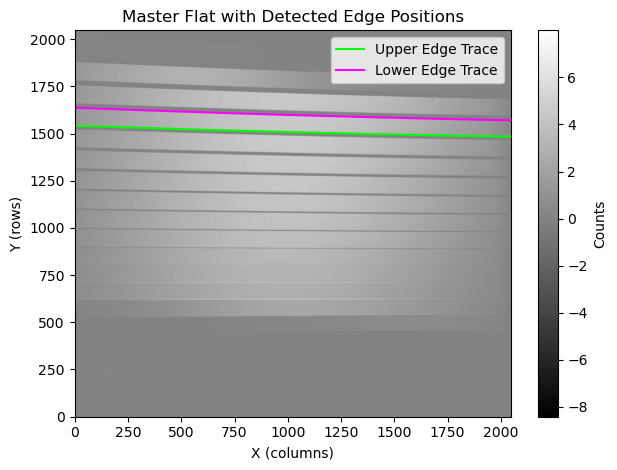

(array([1542.18814291, 1542.14937944, 1542.11062599, ..., 1483.87422897,
        1483.85597175, 1483.83772456]),
 array([1637.40259628, 1637.35867446, 1637.31476366, ..., 1570.60654769,
        1570.58515432, 1570.56377196]))

In [97]:
trace_edges(flat, orders=[70])

In [80]:
def match_positions(reference, candidates, tolerance):
    """
    For each position in `reference`, find the closest position in `candidates`
    within `tolerance` pixels. Returns an array the same length as `reference`,
    with np.nan where no match was found (e.g. a partial order that only
    appears in one section of the detector).
    """
    candidates = np.asarray(candidates, dtype=float)
    matched = np.full(len(reference), np.nan)
    used = set()
    for i, ref_pos in enumerate(reference):
        if len(candidates) == 0:
            continue
        diffs = np.abs(candidates - ref_pos)
        best_idx = np.argmin(diffs)
        if diffs[best_idx] <= tolerance and best_idx not in used:
            matched[i] = candidates[best_idx]
            used.add(best_idx)
    return matched


def trace_edges(masterflat, FILTER=None, window=10, percentile=99,
                show_plots=True, orders=None, match_tolerance=20):
    """Trace spectral order edges in the master flat."""
    print('Tracing edges...')

    if FILTER is None:
        edges = scipy.ndimage.sobel(masterflat, axis=0)
        edges[0:OVERSCAN_WIDTH + 2] = 0

        midsection = np.median(edges[:, int(N/2 - window):int(N/2 + window)], axis=1)
        quarter_section_left = np.median(edges[:, int(N/4 - window):int(N/4 + window)], axis=1)
        quarter_section_right = np.median(edges[:, int(N*3/4 - window):int(N*3/4 + window)], axis=1)

        upper_positions_mid = scipy.signal.find_peaks(midsection,
                                  height=np.percentile(midsection, percentile),
                                  distance=MIN_ORDER_SEPARATION)[0]
        lower_positions_mid = scipy.signal.find_peaks(-midsection,
                                  height=np.percentile(-midsection, percentile),
                                  distance=MIN_ORDER_SEPARATION)[0]
        upper_positions_left = scipy.signal.find_peaks(quarter_section_left,
                                  height=np.percentile(quarter_section_left, percentile),
                                  distance=MIN_ORDER_SEPARATION)[0]
        lower_positions_left = scipy.signal.find_peaks(-quarter_section_left,
                                  height=np.percentile(-quarter_section_left, percentile),
                                  distance=MIN_ORDER_SEPARATION)[0]
        upper_positions_right = scipy.signal.find_peaks(quarter_section_right,
                                  height=np.percentile(quarter_section_right, percentile),
                                  distance=MIN_ORDER_SEPARATION)[0]
        lower_positions_right = scipy.signal.find_peaks(-quarter_section_right,
                                  height=np.percentile(-quarter_section_right, percentile),
                                  distance=MIN_ORDER_SEPARATION)[0]

        # Reference = mid column. Use it as ground truth and match left/right
        # detections to it by position instead of by index, so a spurious or
        # partial detection in one column (e.g. the cut-off top order) doesn't
        # shift every subsequent index out of alignment.
        num_detected = len(upper_positions_mid)
        print(f"  Detected {num_detected} spectral orders (reference: mid column)")
        print(f"  Mid positions: upper={upper_positions_mid}, lower={lower_positions_mid}")
        print(f"  Left positions: upper={upper_positions_left}, lower={lower_positions_left}")
        print(f"  Right positions: upper={upper_positions_right}, lower={lower_positions_right}")

        matched_upper_left = match_positions(upper_positions_mid, upper_positions_left, match_tolerance)
        matched_upper_right = match_positions(upper_positions_mid, upper_positions_right, match_tolerance)
        matched_lower_left = match_positions(lower_positions_mid, lower_positions_left, match_tolerance)
        matched_lower_right = match_positions(lower_positions_mid, lower_positions_right, match_tolerance)

        xs_full = np.array([N/4, N/2, N*3/4])

        if orders is None:
            orders = list(range(num_detected))
        elif isinstance(orders, int):
            orders = [orders]
        elif orders == "all":
            orders = list(range(num_detected))

        orders_resolved = []
        for order_idx in orders:
            resolved_idx = num_detected + order_idx if order_idx < 0 else order_idx
            if resolved_idx < 0 or resolved_idx >= num_detected:
                raise ValueError(f"Order index {order_idx} out of range [0, {num_detected-1}] or [{-num_detected}, -1]")
            orders_resolved.append(resolved_idx)

        print(f"  Tracing order indices: {orders_resolved} (from {num_detected} detected)")

        all_upper_edges = []
        all_lower_edges = []

        for idx in orders_resolved:
            print(f"    Tracing order at index {idx}...")

            ys_upper_full = [matched_upper_left[idx], upper_positions_mid[idx], matched_upper_right[idx]]
            ys_lower_full = [matched_lower_left[idx], lower_positions_mid[idx], matched_lower_right[idx]]

            # Drop any x/y pairs where the side column had no match (partial order)
            ys_upper = [y for y in ys_upper_full if not np.isnan(y)]
            xs_upper = [x for x, y in zip(xs_full, ys_upper_full) if not np.isnan(y)]
            ys_lower = [y for y in ys_lower_full if not np.isnan(y)]
            xs_lower = [x for x, y in zip(xs_full, ys_lower_full) if not np.isnan(y)]

            if len(ys_upper) < 2:
                print(f"    Warning: order {idx} upper edge only detected in one column "
                      f"(likely a partial order) — using it as a flat estimate.")
            if len(ys_lower) < 2:
                print(f"    Warning: order {idx} lower edge only detected in one column "
                      f"(likely a partial order) — using it as a flat estimate.")

            if max(ys_upper) - min(ys_upper) > 20:
                print(f"    Warning: Upper edge positions vary by {max(ys_upper) - min(ys_upper):.1f} pixels across detector")
            if max(ys_lower) - min(ys_lower) > 20:
                print(f"    Warning: Lower edge positions vary by {max(ys_lower) - min(ys_lower):.1f} pixels across detector")

            upper_edges = trace_edge_improved(masterflat, ys_upper, xs_upper, lower_edge=False, window=window)
            lower_edges = trace_edge_improved(masterflat, ys_lower, xs_lower, lower_edge=True, window=window)

            all_upper_edges.append(upper_edges)
            all_lower_edges.append(lower_edges)

            if show_plots:
                plt.imshow(masterflat, origin='lower', aspect='auto', cmap='gray')
                plt.title(f"Master Flat - Order Index {idx}")
                plt.plot(upper_edges, color='lime', label='Upper Edge Trace')
                plt.plot(lower_edges, color='magenta', label='Lower Edge Trace')
                plt.colorbar(label='Counts')
                plt.xlabel("X (columns)")
                plt.ylabel("Y (rows)")
                plt.legend()
                plt.tight_layout()
                plt.show()

        return np.array(all_upper_edges), np.array(all_lower_edges)

Tracing edges...
  Detected 8 spectral orders (reference: mid column)
  Mid positions: upper=[ 894  989 1087 1188 1291 1398 1508 1621], lower=[ 891  984 1079 1177 1278 1381 1488 1598 1712]
  Left positions: upper=[ 897  995 1094 1197 1303 1412 1524 1639 1759], lower=[ 894  989 1087 1187 1290 1395 1504 1617 1732 1852]
  Right positions: upper=[ 892  985 1081 1180 1282 1386 1494 1606], lower=[ 888  979 1073 1169 1268 1370 1475 1583 1695]
  Tracing order indices: [0, 1, 2, 3, 4, 5, 6, 7] (from 8 detected)
    Tracing order at index 0...


/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)
/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)


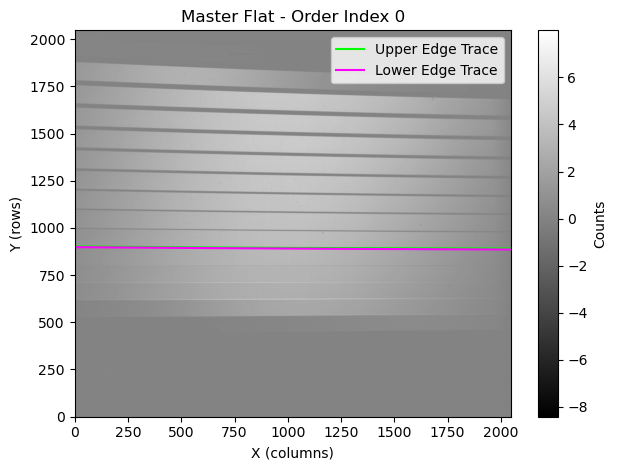

    Tracing order at index 1...


/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)
/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)


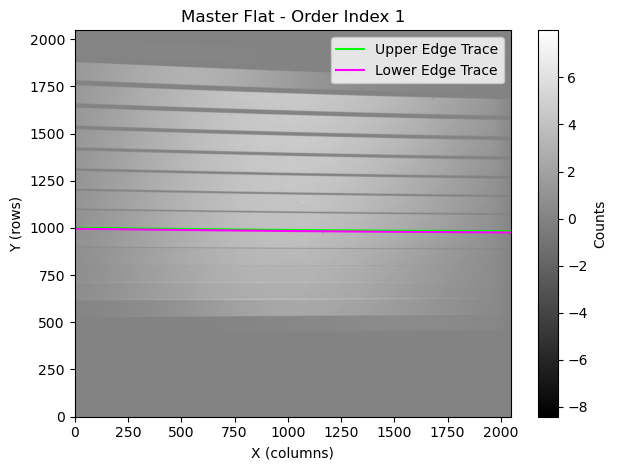

    Tracing order at index 2...


/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)


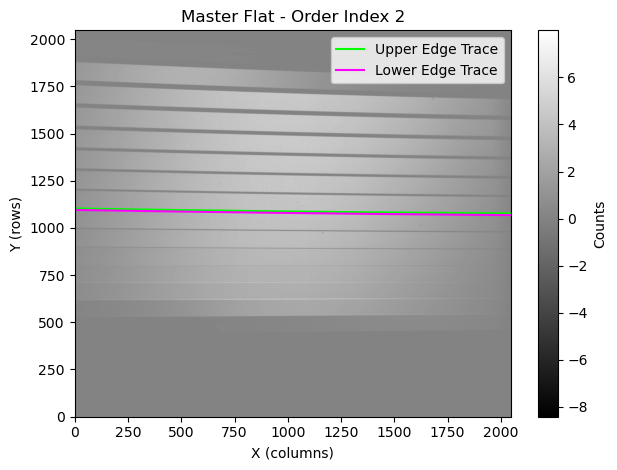

    Tracing order at index 3...


/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)
/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)


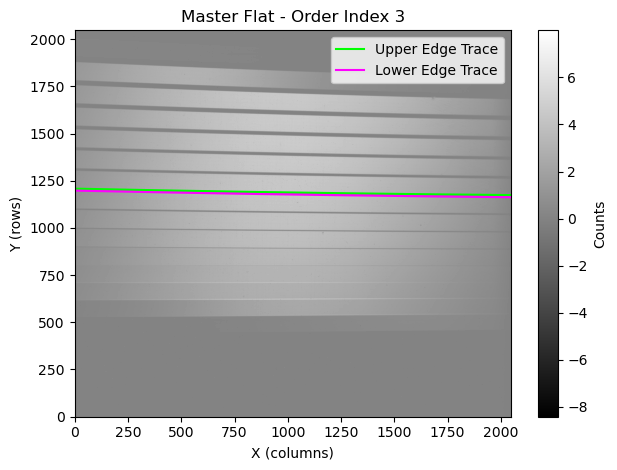

    Tracing order at index 4...


/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)


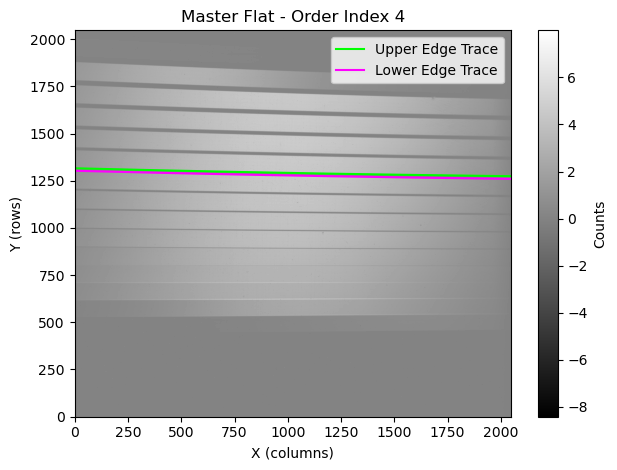

    Tracing order at index 5...


/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)


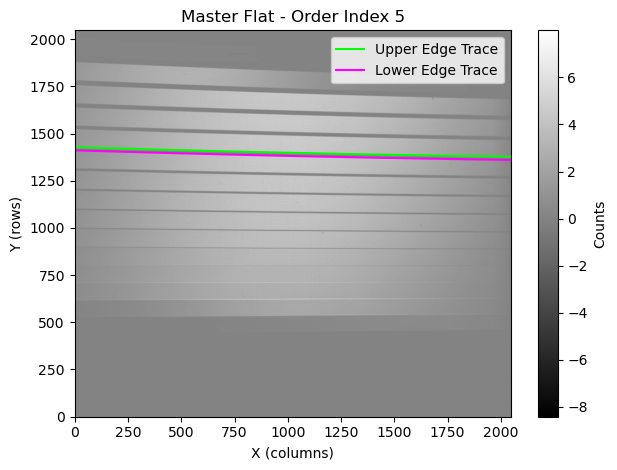

    Tracing order at index 6...


/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)


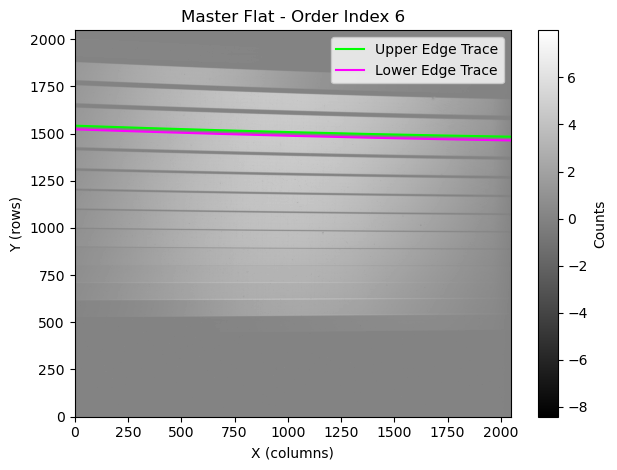

    Tracing order at index 7...


/Users/chase/github/KAHE-pipeline/src/kahe/utils/math.py:66: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, xs, ys, p0=p0, sigma=errors)


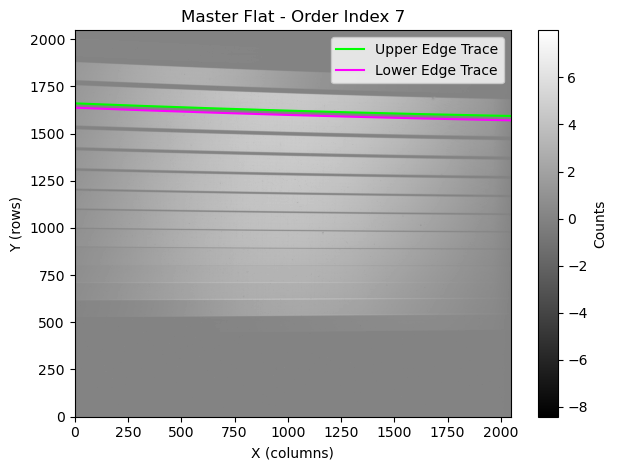

(array([[ 902.21750293,  902.20743416,  902.19736991, ...,  891.05932955,
          891.05849019,  891.05765534],
        [1001.18104145, 1001.16707438, 1001.15311205, ...,  982.53044596,
          982.52617758,  982.52191394],
        [1103.32655565, 1103.30801289, 1103.28947569, ..., 1077.04552041,
         1077.03836602, 1077.0312172 ],
        ...,
        [1427.59700818, 1427.5634874 , 1427.52997545, ..., 1377.51094262,
         1377.49548831, 1377.48004284],
        [1542.18814291, 1542.14937944, 1542.11062599, ..., 1483.87422897,
         1483.85597175, 1483.83772456],
        [1660.43215467, 1660.38800436, 1660.34386533, ..., 1593.72765944,
         1593.70658437, 1593.68552058]]),
 array([[ 898.42934788,  898.42030023,  898.41125543, ...,  885.89858178,
          885.89537726,  885.8921756 ],
        [ 996.01705007,  996.00279377,  995.98854191, ...,  976.14146014,
          976.13628265,  976.1311096 ],
        [1095.62070002, 1095.60181247, 1095.58293033, ..., 1068.29090716,

In [81]:
trace_edges(flat)

In [51]:
top_edges, bottom_edges = trace_edges(flat,
                                      FILTER=None, 
                                      show_plots=True, orders=-3)

Tracing edges...


TypeError: 'int' object is not iterable

As a reference, here is the order numbers in Y band from the line list: 
![here](../calibration/yband_arcs.png)

In [ ]:
top_edges, bottom_edges

(array([[1543.53109918, 1543.48233783, 1543.43361026, ..., 1514.43764039,
         1514.45798228, 1514.47835796]]),
 array([[1637.40635425, 1637.3624249 , 1637.31850658, ..., 1570.60690512,
         1570.58551595, 1570.5641378 ]]))

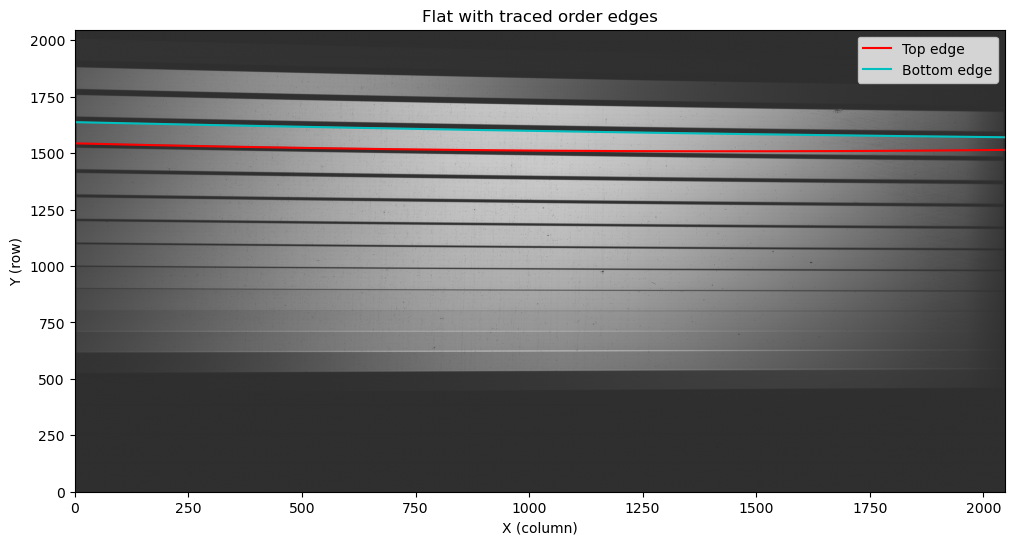

In [ ]:
# Overlay traced edges on the flat
x = np.arange(flat.shape[1])  # columns

plt.figure(figsize=(12, 6))
plt.imshow(flat, cmap="gray", origin="lower", aspect="auto")

top = np.atleast_2d(top_edges)
bot = np.atleast_2d(bottom_edges)

for i in range(top.shape[0]):
    plt.plot(x, top[i], "r-", lw=1.5, label="Top edge" if i == 0 else None)
    plt.plot(x, bot[i], "c-", lw=1.5, label="Bottom edge" if i == 0 else None)

plt.xlim(0, flat.shape[1] - 1)
plt.ylim(0, flat.shape[0] - 1)
plt.legend()
plt.title("Flat with traced order edges")
plt.xlabel("X (column)")
plt.ylabel("Y (row)")
plt.show()